In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/Users/tunasavas/Desktop/football-beyond-xg/data.csv")

df.head()

,Unnamed: 0,group,rank,team,matches_played,wins,draws,losses,goals_scored,goals_against,goal_difference,points,expected_goal_scored,exp_goal_conceded,exp_goal_difference,exp_goal_difference_per_90
0,0,1,1,Netherlands,3,2,1,0,5,1,4,7,2.4,2.7,-0.3,-0.11
1,1,1,2,Senegal,3,2,0,1,5,4,1,6,3.8,2.5,1.3,0.43
2,2,1,3,Ecuador,3,1,1,1,4,3,1,4,3.7,2.6,1.2,0.39
3,3,1,4,Qatar,3,0,0,3,1,7,-6,0,1.4,3.5,-2.1,-0.71
4,4,2,1,England,3,2,1,0,9,2,7,7,5.2,2.3,2.9,0.97


In [91]:
print(df.columns)
print(df.shape)
df.describe()

Index(['Unnamed: 0', 'group', 'rank', 'team', 'matches_played', 'wins',
       'draws', 'losses', 'goals_scored', 'goals_against', 'goal_difference',
       'points', 'expected_goal_scored', 'exp_goal_conceded',
       'exp_goal_difference', 'exp_goal_difference_per_90'],
      dtype='object')
(32, 16)


,Unnamed: 0,group,rank,matches_played,wins,draws,losses,goals_scored,goals_against,goal_difference,points,expected_goal_scored,exp_goal_conceded,exp_goal_difference,exp_goal_difference_per_90
count,32.000000,32.000000,32.000000,32.0,32.000000,32.000000,32.000000,32.000000,32.00000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,15.500000,4.500000,2.500000,3.0,1.187500,0.625000,1.187500,3.750000,3.75000,0.000000,4.187500,3.850000,3.846875,0.006250,-0.000625
std,9.380832,2.327951,1.135924,0.0,0.692704,0.609071,0.780302,2.079082,2.44949,3.282407,1.990907,1.750944,1.883542,3.062461,1.023139
min,0.000000,1.000000,1.000000,3.0,0.000000,0.000000,0.000000,1.000000,1.00000,-8.000000,0.000000,1.400000,0.700000,-8.700000,-2.900000
25%,7.750000,2.750000,1.750000,3.0,1.000000,0.000000,1.000000,2.000000,2.00000,-2.000000,3.000000,2.700000,2.700000,-1.525000,-0.517500
50%,15.500000,4.500000,2.500000,3.0,1.000000,1.000000,1.000000,4.000000,3.00000,0.000000,4.000000,3.700000,3.500000,-0.050000,-0.020000
75%,23.250000,6.250000,3.250000,3.0,2.000000,1.000000,2.000000,5.000000,5.00000,2.000000,6.000000,4.450000,4.600000,1.225000,0.400000
max,31.000000,8.000000,4.000000,3.0,2.000000,2.000000,3.000000,9.000000,11.00000,7.000000,7.000000,10.100000,10.100000,6.700000,2.220000


In [92]:
df["overperform"] = (df["goals_scored"] > df["expected_goal_scored"]).astype(int)

df[["goals_scored", "expected_goal_scored", "overperform"]].head()

,goals_scored,expected_goal_scored,overperform
0,5,2.4,1
1,5,3.8,1
2,4,3.7,1
3,1,1.4,0
4,9,5.2,1


In [93]:
features = [
    "expected_goal_scored",
    "exp_goal_conceded",
    "exp_goal_difference",
    "points",
    "goal_difference",
    "wins"
]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (22, 3)
Test size: (10, 3)


In [95]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print(confusion_matrix(y_test, log_pred))
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.5
[[4 4]
 [1 1]]
              precision    recall  f1-score   support

           0       0.80      0.50      0.62         8
           1       0.20      0.50      0.29         2

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.45        10
weighted avg       0.68      0.50      0.55        10



In [96]:
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print(confusion_matrix(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.3
[[2 6]
 [1 1]]
              precision    recall  f1-score   support

           0       0.67      0.25      0.36         8
           1       0.14      0.50      0.22         2

    accuracy                           0.30        10
   macro avg       0.40      0.38      0.29        10
weighted avg       0.56      0.30      0.34        10



In [97]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.3
              precision    recall  f1-score   support

           0       0.67      0.25      0.36         8
           1       0.14      0.50      0.22         2

    accuracy                           0.30        10
   macro avg       0.40      0.38      0.29        10
weighted avg       0.56      0.30      0.34        10



In [98]:
forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))
print(confusion_matrix(y_test, forest_pred))
print(classification_report(y_test, forest_pred))



model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ]
})

model_results

Random Forest Accuracy: 0.4
[[2 6]
 [0 2]]
              precision    recall  f1-score   support

           0       1.00      0.25      0.40         8
           1       0.25      1.00      0.40         2

    accuracy                           0.40        10
   macro avg       0.62      0.62      0.40        10
weighted avg       0.85      0.40      0.40        10



,Model,Accuracy
0,Logistic Regression,0.5
1,Decision Tree,0.3
2,Random Forest,0.4


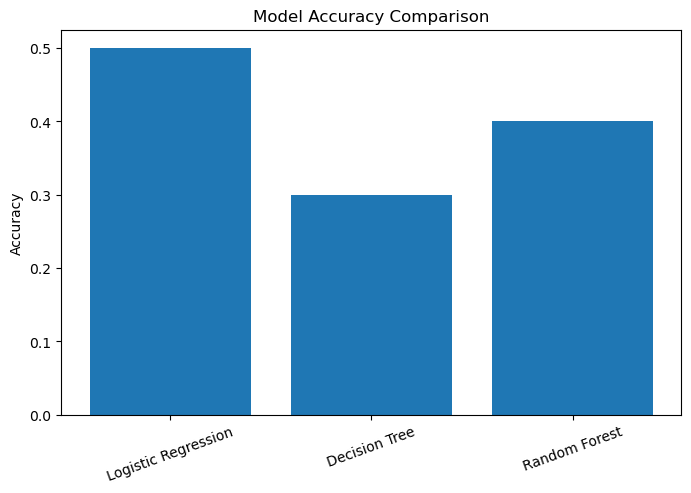

In [99]:
plt.figure(figsize=(8,5))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [100]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances

,Feature,Importance
0,expected_goal_scored,0.391944
2,exp_goal_difference,0.314409
1,exp_goal_conceded,0.293647


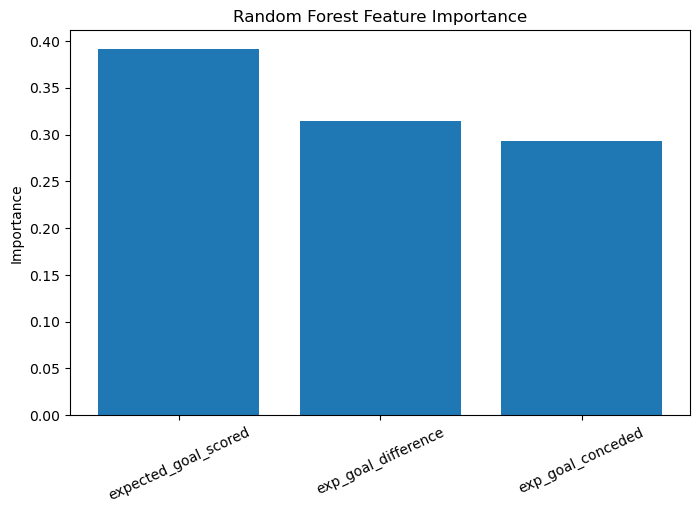

In [101]:
plt.figure(figsize=(8,5))
plt.bar(importances["Feature"], importances["Importance"])
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=25)
plt.show()

The machine learning part of this project predicts whether a team overperforms its expected goals.

The target variable is overperform. It is equal to 1 when actual goals are higher than expected goals, and 0 otherwise.

Three classification models were applied: Logistic Regression, Decision Tree, and Random Forest. The models were compared using accuracy, confusion matrix, and classification report.

The results show that xG-related variables have predictive power, but they do not explain goal outcomes perfectly. This means that finishing quality, luck, and match context can also affect whether a team scores more or less than expected.

In [104]:
# FINAL TEST

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, forest_pred))

print("\nModel Results Table:")
print(model_results)

print("\nShapes check:")
print("y_test:", len(y_test))
print("log_pred:", len(log_pred))
print("tree_pred:", len(tree_pred))
print("forest_pred:", len(forest_pred))

Logistic Regression Accuracy: 0.5
Decision Tree Accuracy: 0.3
Random Forest Accuracy: 0.4

Model Results Table:
                 Model  Accuracy
0  Logistic Regression       0.5
1        Decision Tree       0.3
2        Random Forest       0.4

Shapes check:
y_test: 10
log_pred: 10
tree_pred: 10
forest_pred: 10


The machine learning results show relatively low accuracy across all models. Logistic Regression achieved around 0.5 accuracy, while Decision Tree and Random Forest performed even lower.

This suggests that expected goals (xG) alone is not sufficient to predict whether a team will overperform or underperform.

There are likely other important factors affecting goal outcomes, such as finishing ability, defensive pressure, randomness, and match context.

Overall, the results indicate that while xG is a useful metric, it cannot fully explain real match outcomes.